In [1]:
import Gmsh: gmsh
import Pkg; Pkg.add("Distributions"); Pkg.add("FFTW"); Pkg.add("SpecialFunctions");

using Gridap, GridapGmsh
using Random, LinearAlgebra, FFTW
using Distributions
using Base.Threads
using Plots
using SpecialFunctions #besselk, gamma functions

BLAS.set_num_threads(1)

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [2]:
function create_square_model(h)
    gmsh.initialize()
    gmsh.model.add("unit_square")
    gmsh.model.geo.addPoint(0,0,0,1,1) # last argument is optional identifier, unique per dimension
    gmsh.model.geo.addPoint(1,0,0,1,2)
    gmsh.model.geo.addPoint(1,1,0,1,3)
    gmsh.model.geo.addPoint(0,1,0,1,4)
    gmsh.model.geo.addLine(1,2,1)
    gmsh.model.geo.addLine(2,3,2) # line 2 goes from point 2 to point 3
    gmsh.model.geo.addLine(3,4,3)
    gmsh.model.geo.addLine(4,1,4)
        
    gmsh.model.geo.addCurveLoop([1,2,3,4],1)
        
    gmsh.model.geo.addPlaneSurface([1],1)

    N = Int(round(1/h))  # number of elements per edge

    gmsh.model.geo.mesh.setTransfiniteCurve(1, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(2, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(3, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(4, N+1)

    #triangulation
    gmsh.model.geo.mesh.setTransfiniteSurface(1)

    gmsh.model.geo.synchronize()

    # Define physical groups without the string argument
    edges_tag = gmsh.model.addPhysicalGroup(1, [1, 2, 3, 4])   # edges
    corners_tag = gmsh.model.addPhysicalGroup(0, [1, 2, 3, 4]) # corners
    domain_tag = gmsh.model.addPhysicalGroup(2, [1])           # surface
    
    # Set names for the physical groups
    gmsh.model.setPhysicalName(1, edges_tag, "boundary")
    gmsh.model.setPhysicalName(0, corners_tag, "boundary")
    gmsh.model.setPhysicalName(2, domain_tag, "domain")
    gmsh.model.mesh.generate(2)

    model = GmshDiscreteModel(gmsh);
    gmsh.finalize();
    return model
end

create_square_model (generic function with 1 method)

In [3]:
rho_exp(r, nu, p) = nu^2 * exp(-p*r)

function rho_matern(d, σ, nu, p)
    if d == 0
        return σ^2
    end
    return σ^2 * (2.0^(1-nu) / gamma(nu)) * (sqrt(2*nu) * d / p)^nu *
           besselk(nu, (sqrt(2*nu) * d / p))
end

function algorithm1(m0, σ, nu, p)
    #step 1
    m  = m0
    h0 = 1 / m0

    while true
        ℓ = m * h0
        n = 2m
        s = n^2
        r = zeros(Float64, s) #R_ext is a s x s, so the column r will be a s x 1 vector

        #step 2 calc r
        for k1 in 1:n, k2 in 1:n
            x1 = h0 * (k1-1)
            x2 = h0 * (k2-1)

            #rho_ext = rho(φ(x₁),φ(x₂)) from paper, where φ(x) = x if 0 < x < ℓ or φ(x) = 2ℓ-x if ℓ < x < 2ℓ
            # φ(x₁)
            if x1 < ℓ
                φ1 = x1
            else
                φ1 = 2ℓ - x1
            end
            
            #φ(x₂)
            if x2 < ℓ
                φ2 = x2
            else
                φ2 = 2ℓ - x2
            end

            idx = k1 + (k2-1)*n   #vector ordering
            r[idx] = rho_matern(sqrt(φ1^2 + φ2^2), σ, nu, p)
        end

        #step 3, calc v (in this case λ because I already have variable v)
        λ = real.(fft(reshape(r, n, n))) #reshape to be able to take fft

        #step 4
        if minimum(λ) >= 0
            return m, λ
        end

        m += 1
    end
end

function algorithm2(m, λ, rng)
    #step 1
    n = 2m
    s = n^2
    y = randn(rng, n, n)

    #step 2
    y .*= sqrt.(λ)
    
    #step 3
    w = fft(y) / sqrt(s)

    #step 4
    w = real.(w) .+ imag.(w)

    return w
end

algorithm2 (generic function with 1 method)

In [4]:
h = 2^-5 # target mesh size 
model = create_square_model(h) # fix above function above using the tutorial 
order = 1
reffe = ReferenceFE(lagrangian, Float64, order)
V = TestFESpace(model, reffe, conformity=:H1, dirichlet_tags="boundary")
U = TrialFESpace(V, 0.0)
Ω = Triangulation(model)
dΩ = Measure(Ω, 2 * order)
n = 8
Δt, T = 2.0^(-n), 1 # time step, final time 
num_steps = Int(round(T / Δt))
u₀ = x -> 0.0
v₀ = x -> 0.0
m(u, v) = ∫(u*v)dΩ
k(u, v) = ∫(∇(u) ⋅ ∇(v))dΩ
Mmat = assemble_matrix(m, U, V)
Kmat = assemble_matrix(k, U, V)
Bnoise = assemble_matrix(m, U, V)
LHSpos = (2/Δt)*Mmat + (Δt/2)*Kmat
RHSpos = (2/Δt)*Mmat - (Δt/2)*Kmat
uh0 = interpolate_everywhere(u₀, U) # U^0
vh0 = interpolate_everywhere(v₀, U) # V^0
#parameters for matern cov
σ = 1.0
nu = 0.05
p = 0.3

#CE spacing
ce_h = h
#num of intervals
m0 = Int(round(1/ce_h))
#find embedding size and eigenvalue
m_ce, λ_ce = algorithm1(m0, σ, nu, p)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000432817s, CPU 0.000377s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Transfinite)
Info    : Done meshing 2D (Wall 0.000642394s, CPU 0.000543s)
Info    : 1089 nodes 2180 elements


(32, [263.0202031150701 65.10023935304103 … 9.807195444931963 65.10023935304103; 65.10023935304103 30.459292931706983 … 10.451292667243218 30.459292931706983; … ; 9.807195444931965 10.45129266724322 … 7.159951254194901 10.45129266724322; 65.10023935304103 30.459292931706983 … 10.451292667243218 30.459292931706983])

In [5]:
if !isdir("tmp") mkdir("tmp") end
rng = Xoshiro(1337)

ηh0 = interpolate_everywhere(x -> 0, U)

createpvd("wave") do pvd
    pvd[0.0] = createvtk(Ω,"tmp/stoc_wavev3_0.vtu",cellfields = ["uh"  => uh0,"vh"  => vh0,"eta" => ηh0])

    # dof-vectors
    uvec = get_free_dof_values(uh0) # U^0
    vvec = get_free_dof_values(vh0) # V^0

    for n in 1:num_steps
        t_n = n * Δt

        Z = algorithm2(m_ce, λ_ce, rng)

        function f(x)
            i = clamp(Int(round(x[1] / ce_h)) + 1, 1, m0 + 1)
            j = clamp(Int(round(x[2] / ce_h)) + 1, 1, m0 + 1)
            return sqrt(Δt) * Z[i, j]
        end

        ηh = interpolate_everywhere(f, U)

        zvec = get_free_dof_values(ηh)
        noise = Bnoise * zvec
        # Solve for U^n
        rhs_u = RHSpos * uvec + (2*Mmat) * vvec + 2 * noise
        uvec_new = LHSpos \ rhs_u
        # update V^n
        rhs_v = Mmat * vvec - (Δt/2) * Kmat * (uvec_new + uvec) + noise
        # rhs_v = ((2/Δt) * M) * (uvec_new - uvec) - M*vvec - noise
        vvec_new = Mmat \ rhs_v

        uh = FEFunction(U, uvec_new)
        vh = FEFunction(U, vvec_new)
        
        # save
        vtufilename = "tmp/stoc_wavev3_$(n).vtu"
        pvd[t_n] = createvtk(Ω,vtufilename,cellfields = ["uh"  => uh,"vh"  => vh,"eta" => ηh])
        # update
        uvec = uvec_new
        vvec = vvec_new
    end
end

258-element Vector{String}:
 "wave.pvd"
 "tmp/stoc_wavev3_0.vtu"
 "tmp/stoc_wavev3_1.vtu"
 "tmp/stoc_wavev3_2.vtu"
 "tmp/stoc_wavev3_3.vtu"
 "tmp/stoc_wavev3_4.vtu"
 "tmp/stoc_wavev3_5.vtu"
 "tmp/stoc_wavev3_6.vtu"
 "tmp/stoc_wavev3_7.vtu"
 "tmp/stoc_wavev3_8.vtu"
 "tmp/stoc_wavev3_9.vtu"
 "tmp/stoc_wavev3_10.vtu"
 "tmp/stoc_wavev3_11.vtu"
 ⋮
 "tmp/stoc_wavev3_245.vtu"
 "tmp/stoc_wavev3_246.vtu"
 "tmp/stoc_wavev3_247.vtu"
 "tmp/stoc_wavev3_248.vtu"
 "tmp/stoc_wavev3_249.vtu"
 "tmp/stoc_wavev3_250.vtu"
 "tmp/stoc_wavev3_251.vtu"
 "tmp/stoc_wavev3_252.vtu"
 "tmp/stoc_wavev3_253.vtu"
 "tmp/stoc_wavev3_254.vtu"
 "tmp/stoc_wavev3_255.vtu"
 "tmp/stoc_wavev3_256.vtu"

## Convergence Testing ##

In [6]:
function EMpath_stoch_time(uh0, vh0, T, Nref, kappa, facLHS, facM, Mmat, Kmat, noise_ref)
    #fine (reference) time step
    Dtref = T / Nref
    #coarse time step
    Dt = kappa * Dtref
    #num coarse steps
    NN = div(Nref, kappa)
    #precompute to avoid doing it for every timestep
    a = 2 / Dt
    b = Dt / 2

    #copy uh0 and vh0 to avoid modifying the original
    uvec = copy(get_free_dof_values(uh0))
    vvec = copy(get_free_dof_values(vh0))

    #allocate memory for all the arrays in the loop to avoid allocating garbage every time step
    uvec_new = similar(uvec)
    vvec_new = similar(uvec)
    Mu = similar(uvec)
    Ku = similar(uvec)
    Mv = similar(uvec)
    usum = similar(uvec)
    rhs_u = similar(uvec)
    rhs_v = similar(uvec)

    #holds the summed noise over one time step
    noise = zeros(eltype(uvec), length(uvec))

    for n in 1:NN
        fill!(noise, 0.0) #resets the summed noise
        #sum the fine kappa increments
        @inbounds for r in 1:kappa
            noise .+= noise_ref[(n-1)*kappa + r]
        end

        #Mu = Mmat * uve
        mul!(Mu, Mmat, uvec)
        #Ku = Kmat * uvec
        mul!(Ku, Kmat, uvec)
        #Mv = Mmat * vvec
        mul!(Mv, Mmat, vvec)
        #rhs_u = (2/Dt) * M*u - (Dt/2) * K*u + 2*M*v + 2*noise
        rhs_u .= a .* Mu .- b .* Ku .+ 2.0 .* Mv .+ 2.0 .* noise
        copyto!(uvec_new, rhs_u)
        ldiv!(facLHS, uvec_new)
        
        #usum = uvec_new + uvec
        usum .= uvec_new .+ uvec
        #Ku = Kmat * (uvec_new + uvec)
        mul!(Ku, Kmat, usum)
        #rhs_v = M*v - (Dt/2) * K*(u_new + u_old) + noise
        rhs_v .= Mv .- b .* Ku .+ noise
        copyto!(vvec_new, rhs_v)
        ldiv!(facM, vvec_new)

        uvec, uvec_new = uvec_new, uvec
        vvec, vvec_new = vvec_new, vvec
    end

    return uvec
end

function EMpath_space(uh0, vh0, num_steps, Δt, facLHS, facM, Mmat, Kmat, noise_loads)
    a = 2 / Δt
    b = Δt / 2

    uvec = copy(get_free_dof_values(uh0))
    vvec = copy(get_free_dof_values(vh0))

    uvec_new = similar(uvec)
    vvec_new = similar(uvec)

    Mu = similar(uvec)
    Ku = similar(uvec)
    Mv = similar(uvec)
    usum = similar(uvec)

    rhs_u = similar(uvec)
    rhs_v = similar(uvec)

    for n in 1:num_steps
        #noise for this exact time step and exact spatial mesh.
        noise = noise_loads[n]

        mul!(Mu, Mmat, uvec)
        mul!(Ku, Kmat, uvec)
        mul!(Mv, Mmat, vvec)
        
        #rhs_u = (2/Dt) * M*u - (Dt/2) * K*u + 2*M*v + 2*noise
        rhs_u .= a .* Mu .- b .* Ku .+ 2.0 .* Mv .+ 2.0 .* noise
        copyto!(uvec_new, rhs_u)
        ldiv!(facLHS, uvec_new)

        usum .= uvec_new .+ uvec
        mul!(Ku, Kmat, usum)
        #rhs_v = M*v - (Dt/2) * K*(u_new + u_old) +noise
        rhs_v .= Mv .- b .* Ku .+ noise
        copyto!(vvec_new, rhs_v)
        ldiv!(facM, vvec_new)

        uvec, uvec_new = uvec_new, uvec
        vvec, vvec_new = vvec_new, vvec
    end

    return uvec
end

EMpath_space (generic function with 1 method)

In [14]:
function runEMpath_stoch_time(uh0, vh0, T, Nref, kappas, Nsamp, Mmat, Kmat, m0, m_ce, λ_ce, ce_h, U, Bnoise)
    nk = length(kappas) #number of kappas
    Dtref = T / Nref #time step for reference
    ndofs = size(Mmat,1) #number of degrees of freedom in space

    partial_sums = [zeros(nk) for _ in 1:nthreads()] #one vector per thread to compute sum and avoid race conditions

    facM = lu(Mmat) # pre-LU factorization of mass matrix
    
    # pre-LU factorize the LHS matrix of the ref
    Dt1 = Dtref
    LHSpos1 = (2 / Dt1) * Mmat + (Dt1 / 2) * Kmat
    facLHS1 = lu(LHSpos1)

    # pre-LU factorize the LHS matrix for the kappas
    facLHS_list = Vector{typeof(facLHS1)}(undef, nk)
    for (i, kappa) in enumerate(kappas)
        Dt = kappa * Dtref
        LHSpos = (2 / Dt) * Mmat + (Dt / 2) * Kmat
        facLHS_list[i] = lu(LHSpos)
    end

    #this replaces the old "rng = Xoshiro(1337)" inside each sample loop.
    rng = Xoshiro(1337)

    #store one fine grid noise path per Monte Carlo sample
    noise_refs = Vector{Vector{Vector{Float64}}}(undef, Nsamp)

    #build all fine time noise loads before
    for samp in 1:Nsamp
        noise_ref = Vector{Vector{Float64}}(undef, Nref) #stores the fine grid noise loads for all fine time steps.

        #builds fine time noise loads.
        for n in 1:Nref
            Z = algorithm2(m_ce, λ_ce, rng)

            function f(x)
                i = clamp(Int(round(x[1] / ce_h)) + 1, 1, m0 + 1)
                j = clamp(Int(round(x[2] / ce_h)) + 1, 1, m0 + 1)
                return sqrt(Dtref) * Z[i, j]
            end

            ηh = interpolate_everywhere(f, U)
            zvec = get_free_dof_values(ηh)
            noise_ref[n] = Bnoise * zvec
        end

        noise_refs[samp] = noise_ref
    end
    
    @threads for samp in 1:Nsamp
        tid = threadid() # thread index
        local_sum = partial_sums[tid] # the thread's own vector to compute sum later

        #pick the generated noise path for this MC sample
        noise_ref = noise_refs[samp]

        uref = EMpath_stoch_time(uh0, vh0, T, Nref, 1, facLHS1, facM, Mmat, Kmat, noise_ref)

        Merr = zeros(ndofs) #allocate vector to avoid new ones being created for every kappa

        for (i, kappa) in enumerate(kappas)
            u = EMpath_stoch_time(uh0, vh0, T, Nref, kappa, facLHS_list[i], facM, Mmat, Kmat, noise_ref)

            #compute error
            erru = u - uref
            mul!(Merr, Mmat, erru)
            local_sum[i] += dot(erru, Merr)
        end
    end


    S_u = zeros(nk)
    for ps in partial_sums
        S_u .+= ps
    end

    return sqrt.(S_u ./ Nsamp)
end


function runEMpath_stoch_space(T, Nref, kappas, Nsamp)
    nk = length(kappas) #number of kappas
    
    #reference mesh first, then coarse meshes
    N_list = [Nref; Int.(Nref ./ kappas)]

    #fixed time step
    n_time = 8
    Δt = 2.0^(-n_time)
    num_steps = Int(round(T / Δt))

    #storage for matrices
    M_list      = Vector{Any}(undef, nk+1)
    K_list      = Vector{Any}(undef, nk+1)
    U_list      = Vector{Any}(undef, nk+1)
    V_list      = Vector{Any}(undef, nk+1)
    Bnoise_list = Vector{Any}(undef, nk+1)
    uh0_list    = Vector{Any}(undef, nk+1)
    vh0_list    = Vector{Any}(undef, nk+1)

    order = 1
    reffe = ReferenceFE(lagrangian, Float64, order)

    #build all meshes
    for i in 1:(nk+1)
        N = N_list[i]
        h = 1 / N

        model = create_square_model(h)

        V = TestFESpace(model, reffe, conformity=:H1, dirichlet_tags="boundary")
        U_list[i] = TrialFESpace(V, 0.0)
        V_list[i] = V

        Ω = Triangulation(model)
        dΩ = Measure(Ω, 2 * order)

        m(u,v) = ∫(u*v)dΩ
        k(u,v) = ∫(∇(u) ⋅ ∇(v))dΩ

        M_list[i] = assemble_matrix(m, U_list[i], V)
        K_list[i] = assemble_matrix(k, U_list[i], V)
        Bnoise_list[i] = assemble_matrix(m, U_list[i], V)

        uh0_list[i] = interpolate_everywhere(x -> 0.0, U_list[i])
        vh0_list[i] = interpolate_everywhere(x -> 0.0, U_list[i])
    end
    
    #factorizations
    facM_list = [lu(M_list[i]) for i in 1:(nk+1)]
    facLHS_list = [lu((2/Δt)*M_list[i] + (Δt/2)*K_list[i]) for i in 1:(nk+1)]

    partial_sums = [zeros(nk) for _ in 1:nthreads()]

    #reference objects
    Mref = M_list[1]
    Uref = U_list[1]

    #CE params for reference
    ce_h = 1 / Nref
    σ = 1.0
    nu = 0.4
    p = 0.15

    #number of intervals on the reference CE grid
    m0 = Int(round(1/ce_h))

    #find embedding size and eigenvalue for the reference CE grid
    m_ce, λ_ce = algorithm1(m0, σ, nu, p)

    rng = Xoshiro(1337)

    #store one reference CE path per Monte Carlo sample
    Zs_list = Vector{Vector{Matrix{Float64}}}(undef, Nsamp)

    #build all CE realizations before 
    for samp in 1:Nsamp
        #generate one reference CE grid per time step.
        Z_list = Vector{Matrix{Float64}}(undef, num_steps)
        for n in 1:num_steps
            Z_list[n] = algorithm2(m_ce, λ_ce, rng)
        end

        Zs_list[samp] = Z_list
    end

    @threads for samp in 1:Nsamp
        tid = threadid()
        local_sum = partial_sums[tid]

        #pick the generated CE path for this sample
        Z_list = Zs_list[samp]
         
        #for each spatial size (kappa), store one noise load vector per time step.
        noise_loads_list = [Vector{Vector{Float64}}(undef, num_steps) for _ in 1:(nk+1)]

        for n in 1:num_steps
            Z = Z_list[n]

            for j in 1:(nk+1)
                function f(x)
                    ii = clamp(Int(round(x[1] / ce_h)) + 1, 1, m0 + 1)
                    jj = clamp(Int(round(x[2] / ce_h)) + 1, 1, m0 + 1)
                    return sqrt(Δt) * Z[ii, jj]
                end

                ηh = interpolate_everywhere(f, U_list[j])
                zvec = get_free_dof_values(ηh)
                noise_loads_list[j][n] = Bnoise_list[j] * zvec
            end
        end

        uref = EMpath_space(uh0_list[1], vh0_list[1], num_steps, Δt, facLHS_list[1], facM_list[1], M_list[1], K_list[1], noise_loads_list[1])

        Merr = similar(uref)

        for i in 1:nk
            idx = i + 1 #skip ref mesh

            u = EMpath_space(uh0_list[idx], vh0_list[idx], num_steps, Δt, facLHS_list[idx], facM_list[idx], M_list[idx], K_list[idx], noise_loads_list[idx])

            #coarse FE function
            uh = FEFunction(U_list[idx], u)

            #interpolate coarse solution onto reference space
            uh_ref = interpolate_everywhere(x -> uh(x), Uref)
            u_interp = get_free_dof_values(uh_ref)

            # error
            err = u_interp - uref
            mul!(Merr, Mref, err)
            local_sum[i] += dot(err, Merr)
        end
    end

    S = zeros(nk)
    for ps in partial_sums
        S .+= ps
    end

    return sqrt.(S ./ Nsamp)
end


runEMpath_stoch_space (generic function with 1 method)

In [8]:
T = 1
kappas = [2,4,8,16,32,64,128,256,512,1024,2048]
Nref = 2^15
Nsamp = 10
Dtref = T / Nref
dts = kappas .* Dtref

@time begin
    rms_u_time = runEMpath_stoch_time(uh0, vh0, T, Nref, kappas, Nsamp, Mmat, Kmat, m0, m_ce, λ_ce, ce_h, U, Bnoise)
end

println("number of threads:")
println(nthreads())

println("----------------------------TIME----------------------------")
println("dt values:")
println(dts)
println("RMS errors:")
println(rms_u_time)
println("------------------------------------------------------------")

println("")

┌ Info: waiting for UmfpackLU's lock, it's safe to ignore this message.
└ see the documentation for Umfpack


148.247598 seconds (2.19 G allocations: 196.110 GiB, 10.49% gc time, 1020952 lock conflicts, 8.62% compilation time)
number of threads:
20
----------------------------TIME----------------------------
dt values:
[6.103515625e-5, 0.0001220703125, 0.000244140625, 0.00048828125, 0.0009765625, 0.001953125, 0.00390625, 0.0078125, 0.015625, 0.03125, 0.0625]
RMS errors:
[1.1839245508147206e-5, 3.314913957262501e-5, 6.926851846314159e-5, 0.00014797211688913524, 0.0003026593751503779, 0.0007814073315354654, 0.0023025331523776993, 0.004332847896742754, 0.007046963353278437, 0.011350532164760773, 0.016674486196690777]
------------------------------------------------------------



In [15]:
T = 1
Nref_space = 2^6
kappas_space = [2,4,8,16,32]
Nsamp_space = 10
lenref = 1 / Nref_space
hs = kappas_space .* lenref

@time begin
    rms_u_space = runEMpath_stoch_space(T, Nref_space, kappas_space, Nsamp_space)
end

println("----------------------------SPACE----------------------------")
println("h values:")
println(hs)
println("RMS errors:")
println(rms_u_space)
println("-------------------------------------------------------------")

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000198254s, CPU 0.000201s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Transfinite)
Info    : Done meshing 2D (Wall 0.000510755s, CPU 0.000493s)
Info    : 4225 nodes 8452 elements
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000132698s, CPU 0.000139s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Transfinite)
Info    : Done meshing 2D (Wall 0.000177238s, CPU 0.000173s)
Info    : 1089 nodes 2180 elements
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
In

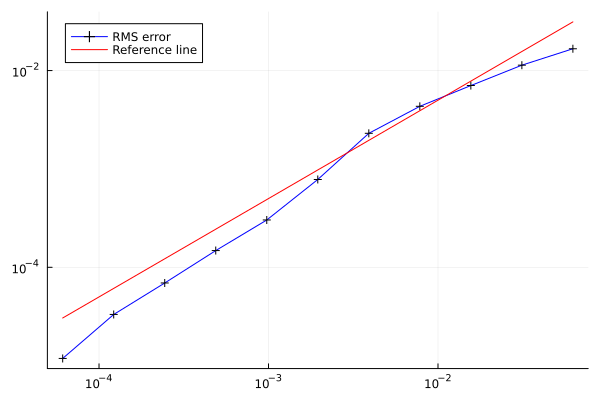

In [16]:
x = range(minimum(dts), maximum(dts), 100)
plot(dts, rms_u_time, xaxis=:log, yaxis=:log, marker=:cross,markercolor=:black, linecolor=:blue, label="RMS error")
plot!(x, 0.5*x.^1, xaxis=:log, yaxis=:log,linecolor=:red, label="Reference line")


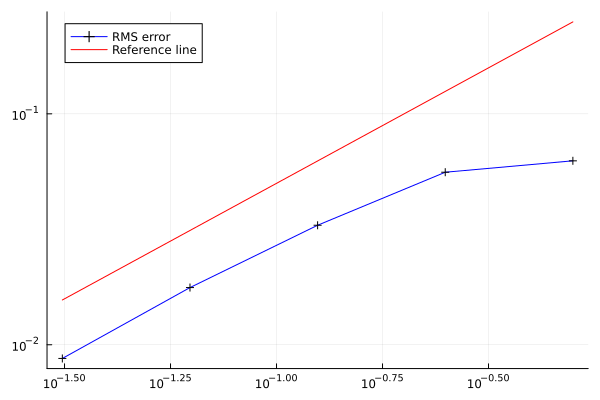

In [17]:
y = range(minimum(hs), maximum(hs), 100)
plot(hs, rms_u_space, xaxis=:log, yaxis=:log, marker=:cross,markercolor=:black, linecolor=:blue, label="RMS error")
plot!(y, 0.5*y.^1, xaxis=:log, yaxis=:log,linecolor=:red, label="Reference line")